# AAI5025 FINAL PROJECT Notebook

## The Customer Intelligence Pipeline (Modules 2-14 Capstone)

This project simulates a real-world data science pipeline, requiring you to apply all major concepts from the course: SQL data acquisition, Pandas wrangling, NumPy calculations, NLP feature engineering, visualization, and predictive modeling (Regression, Clustering, Classification).



## Setup: Library, Functions, and Method Imports

In [16]:
"""
AAI5025 Final Project: Customer Intelligence Pipeline
======================================================
This notebook implements a complete data science pipeline including:
1. Data acquisition from SQLite database
2. Data cleaning and wrangling
3. Feature engineering (numerical and NLP-based)
4. Exploratory data analysis with visualizations
5. Predictive modeling (Regression, Clustering, Classification)

Ruthvik Nath Bandari
December 2025
"""

# IMPORT LIBRARIES

# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Database connectivity
import sqlite3

# NLP for sentiment analysis
from textblob import TextBlob

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models and utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, accuracy_score, classification_report

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully!")

All libraries imported successfully!


## Data Acquisition (M13, M8)

**Goal**: Connect to the provided database file (`user_data.db`) and load the data directly into a Pandas DataFrame.

-------------------------------------------

### Task 1.1: Database Connection and Query

Ensure the file `user_data.db` is in the same directory as this notebook.

Write a SQL query that selects **ALL columns** from the `customer_reviews` table.

Use Pandas to execute the query and load the result into a DataFrame named `df`.

In [17]:
# Define database path
DATABASE_PATH = 'user_data.db'

# SQL query to select all data from customer_reviews table
query = "SELECT * FROM customer_reviews"

# Connect to database and load data using context manager
with sqlite3.connect(DATABASE_PATH) as conn:
    df = pd.read_sql_query(query, conn)

# Display initial data overview
print(f"Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:")
df.head()

Dataset Shape: 1002 rows x 7 columns

Column Names: ['ID', 'Gender', 'Education', 'Raw_Income', 'Total_Spend', 'Avg_Visits', 'Review_Text']

Data Types:
ID               int64
Gender          object
Education       object
Raw_Income      object
Total_Spend    float64
Avg_Visits       int64
Review_Text     object
dtype: object

First 5 Rows:


,ID,Gender,Education,Raw_Income,Total_Spend,Avg_Visits,Review_Text
0,1,Male,Bachelors,36000,683.26,6,Just the facts: it is bad (Ref:1-227).
1,2,Female,Masters,"$107,000",1090.29,22,My experience with this: expensive (Ref:2-467).
2,3,Male,Masters,20000,597.91,18,My opinion: it is frustrating (Ref:3-620).
3,4,Male,Masters,"$20,000",143.21,5,Just the facts: it is bad (Ref:4-150).
4,5,Male,Bachelors,"$41,000",486.49,17,I felt it was functional (Ref:5-886).


## PART A: Data Wrangling and Feature Engineering (M6, M8, M4)

**Goal:** Clean inconsistent data formats and create new features using functions and string methods.

---------------------------

### Task A.1: Data Cleaning (Raw_Income)

The Raw_Income column is a string (object) and contains '$' and ',' characters, preventing calculation.

Use a string method chain (.str.replace(), .astype()) to convert this column to a clean float.

In [19]:
"""
Cleaning the Raw_Income column by removing currency formatting:
1. Remove '$' symbols
2. Remove ',' thousands separators
3. Convert to float type

Using vectorized string operations for efficiency (no Python loops).
"""

# Display sample of original messy data
print("Original Raw_Income (sample):")
print(df['Raw_Income'].head(10).tolist())

# Clean the Raw_Income column using vectorized string operations
# Chain: remove '$' -> remove ',' -> convert to float
df['Clean_Income'] = (
    df['Raw_Income']
    .str.replace('$', '', regex=False)  # Remove dollar signs
    .str.replace(',', '', regex=False)  # Remove commas
    .astype(float)                       # Convert to float
)

# Verify the cleaning operation
print(f"\nClean_Income Data Type: {df['Clean_Income'].dtype}")
print(f"\nClean_Income Statistics:")
print(df['Clean_Income'].describe())

Original Raw_Income (sample):
['36000', '$107,000', '20000', '$20,000', '$41,000', '21000', '$134,000', '$89,000', '$20,000', '$20,000']

Clean_Income Data Type: float64

Clean_Income Statistics:
count      1002.000000
mean      53814.371257
std       38715.585705
min       20000.000000
25%       20000.000000
50%       41000.000000
75%       78750.000000
max      209000.000000
Name: Clean_Income, dtype: float64


### Task A.2: Wrangling and Imputation

Handle missing values and duplicate rows.

In [20]:
"""
Handling data quality issues:
1. Replace string 'nan' with actual NaN values
2. Impute missing Education values with mode (most frequent)
3. Remove duplicate rows
"""

# Check initial data quality
print("=== Initial Data Quality Assessment ===")
print(f"\nEducation Value Counts (before cleaning):")
print(df['Education'].value_counts(dropna=False))
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Step 1: Replace string 'nan' with actual NaN
df['Education'] = df['Education'].replace('nan', np.nan)

# Step 2: Impute missing Education values with mode (most common value)
education_mode = df['Education'].mode()[0]
df['Education'] = df['Education'].fillna(education_mode)
print(f"\nEducation imputed with mode: '{education_mode}'")

# Step 3: Remove duplicate rows
initial_rows = len(df)
df = df.drop_duplicates()
rows_removed = initial_rows - len(df)
print(f"Duplicate rows removed: {rows_removed}")

# Verify cleaning results
print(f"\n=== Post-Cleaning Verification ===")
print(f"\nEducation Value Counts (after cleaning):")
print(df['Education'].value_counts())
print(f"\nMissing Values Per Column:")
print(df.isnull().sum())
print(f"\nFinal Dataset Shape: {df.shape}")

=== Initial Data Quality Assessment ===

Education Value Counts (before cleaning):
Education
Bachelors      586
Masters        202
nan            117
High School     97
Name: count, dtype: int64

Duplicate Rows: 2

Education imputed with mode: 'Bachelors'
Duplicate rows removed: 2

=== Post-Cleaning Verification ===

Education Value Counts (after cleaning):
Education
Bachelors      701
Masters        202
High School     97
Name: count, dtype: int64

Missing Values Per Column:
ID              0
Gender          0
Education       0
Raw_Income      0
Total_Spend     0
Avg_Visits      0
Review_Text     0
Clean_Income    0
dtype: int64

Final Dataset Shape: (1000, 8)


### Task A.3: Feature Engineering (M4, M14)

A. **Spend per Visit** (a.k.a, average spend per visit): Create this new numerical feature .

In [21]:
"""
Creating derived feature representing average customer spending per store visit.
This metric indicates customer value and loyalty patterns.
Formula: Spend_per_Visit = Total_Spend / Avg_Visits
"""

# Create Spend_per_Visit using vectorized division
df['Spend_per_Visit'] = df['Total_Spend'] / df['Avg_Visits']

# Display statistics for the new feature
print("Spend_per_Visit Feature Statistics:")
print(df['Spend_per_Visit'].describe())
print(f"\nSample Values:")
print(df[['Total_Spend', 'Avg_Visits', 'Spend_per_Visit']].head(10))

Spend_per_Visit Feature Statistics:
count    1000.000000
mean       44.398602
std        27.141139
min         0.460000
25%        32.719152
50%        40.788062
75%        49.986067
max       437.770000
Name: Spend_per_Visit, dtype: float64

Sample Values:
   Total_Spend  Avg_Visits  Spend_per_Visit
0       683.26           6       113.876667
1      1090.29          22        49.558636
2       597.91          18        33.217222
3       143.21           5        28.642000
4       486.49          17        28.617059
5        81.12           4        20.280000
6       827.12          20        41.356000
7       856.93          22        38.951364
8       871.32          20        43.566000
9       234.71           5        46.942000


B. **Review Word Count:** Create this new NLP feature that counts the number of words in each review text.

In [23]:
"""
Creating NLP feature counting words in each customer review.
Longer reviews may indicate stronger customer engagement.
Using vectorized string operations for efficiency.
"""

# Create Review_Word_Count using vectorized string split and length count
df['Review_Word_Count'] = df['Review_Text'].str.split().str.len()

# Display statistics for the new feature
print("Review_Word_Count Feature Statistics:")
print(df['Review_Word_Count'].describe())
print(f"\nSample Values:")
print(df[['Review_Text', 'Review_Word_Count']].head())

Review_Word_Count Feature Statistics:
count    1000.000000
mean        8.841000
std         2.490768
min         6.000000
25%         6.000000
50%         9.000000
75%        10.000000
max        15.000000
Name: Review_Word_Count, dtype: float64

Sample Values:
                                       Review_Text  Review_Word_Count
0           Just the facts: it is bad (Ref:1-227).                  7
1  My experience with this: expensive (Ref:2-467).                  6
2       My opinion: it is frustrating (Ref:3-620).                  6
3           Just the facts: it is bad (Ref:4-150).                  7
4            I felt it was functional (Ref:5-886).                  6


## PART B: Text Analysis and Correlation (M14, M10)

**Goal:** Generate sentiment scores and check for correlation between NLP features and numerical features.

-----------------

### Task B.1: Sentiment Analysis (M14)

Calculate the Polarity score for the Review_Text.

In [25]:
"""
Generating sentiment polarity scores for each customer review.
Polarity ranges from -1 (negative) to +1 (positive).
Using apply() with lambda for efficient sentiment extraction.
"""

def get_sentiment_polarity(text):
    """
    Extract sentiment polarity from text using TextBlob.
    
    Parameters:
        text (str): Input text to analyze
        
    Returns:
        float: Polarity score between -1 and 1
    """
    return TextBlob(str(text)).sentiment.polarity

# Calculate Sentiment_Score for each review
df['Sentiment_Score'] = df['Review_Text'].apply(get_sentiment_polarity)

# Display sentiment statistics
print("Sentiment_Score Statistics:")
print(df['Sentiment_Score'].describe())

# Categorize sentiments for insight
print(f"\nSentiment Distribution:")
print(f"  Positive (>0): {(df['Sentiment_Score'] > 0).sum()}")
print(f"  Neutral (=0):  {(df['Sentiment_Score'] == 0).sum()}")
print(f"  Negative (<0): {(df['Sentiment_Score'] < 0).sum()}")

# Show sample reviews with their sentiment scores
print(f"\nSample Reviews with Sentiment Scores:")
print(df[['Review_Text', 'Sentiment_Score']].head(10))

Sentiment_Score Statistics:
count    1000.00000
mean       -0.08600
std         0.49137
min        -1.00000
25%        -0.42000
50%         0.00000
75%         0.15000
max         1.00000
Name: Sentiment_Score, dtype: float64

Sentiment Distribution:
  Positive (>0): 292
  Neutral (=0):  253
  Negative (<0): 455

Sample Reviews with Sentiment Scores:
                                         Review_Text  Sentiment_Score
0             Just the facts: it is bad (Ref:1-227).           -0.700
1    My experience with this: expensive (Ref:2-467).           -0.500
2         My opinion: it is frustrating (Ref:3-620).           -0.400
3             Just the facts: it is bad (Ref:4-150).           -0.700
4              I felt it was functional (Ref:5-886).            0.000
5  My friends also agree that it is frustrating (...           -0.400
6  My friends also agree that it is functional (R...            0.000
7        Just the facts: it is terrible (Ref:8-754).           -1.000
8  I thought the 

### Task B.2: Correlation Analysis (M10)

Calculate and state the correlation between the following two features:

`Review_Word_Count` and  `Sentiment_Score`

In [26]:
"""
Calculating Pearson correlation between Review_Word_Count and Sentiment_Score.
This reveals whether longer reviews tend to be more positive or negative.
"""

# Calculate correlation coefficient
correlation = df['Review_Word_Count'].corr(df['Sentiment_Score'])

print(f"=== Correlation Analysis ===")
print(f"\nCorrelation between Review_Word_Count and Sentiment_Score: {correlation:.4f}")

# Interpret the correlation strength
if abs(correlation) < 0.3:
    strength = "weak"
elif abs(correlation) < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if correlation > 0 else "negative"

print(f"\nInterpretation: There is a {strength} {direction} correlation.")
print(f"This suggests that review length has {'little' if strength == 'weak' else 'some'} relationship with sentiment.")

# Display full correlation matrix for numerical features
print(f"\n=== Full Correlation Matrix (Numerical Features) ===")
numerical_cols = ['Clean_Income', 'Total_Spend', 'Avg_Visits', 'Spend_per_Visit', 
                  'Review_Word_Count', 'Sentiment_Score']
print(df[numerical_cols].corr().round(4))

=== Correlation Analysis ===

Correlation between Review_Word_Count and Sentiment_Score: 0.1189

Interpretation: There is a weak positive correlation.
This suggests that review length has little relationship with sentiment.

=== Full Correlation Matrix (Numerical Features) ===
                   Clean_Income  Total_Spend  Avg_Visits  Spend_per_Visit  \
Clean_Income             1.0000       0.3991      0.3307           0.0255   
Total_Spend              0.3991       1.0000      0.8818           0.0688   
Avg_Visits               0.3307       0.8818      1.0000          -0.2394   
Spend_per_Visit          0.0255       0.0688     -0.2394           1.0000   
Review_Word_Count       -0.0766      -0.0166     -0.0101           0.0322   
Sentiment_Score          0.1654       0.3214      0.2892          -0.0109   

                   Review_Word_Count  Sentiment_Score  
Clean_Income                 -0.0766           0.1654  
Total_Spend                  -0.0166           0.3214  
Avg_Visits    

## PART C: Visualization (M9)


**Goal:** Create visualizations to answer specific data questions, following best practices.

------------------

### Task C.1: Distribution (Histogram)

Create a Histogram showing the distribution of the clean Income column.

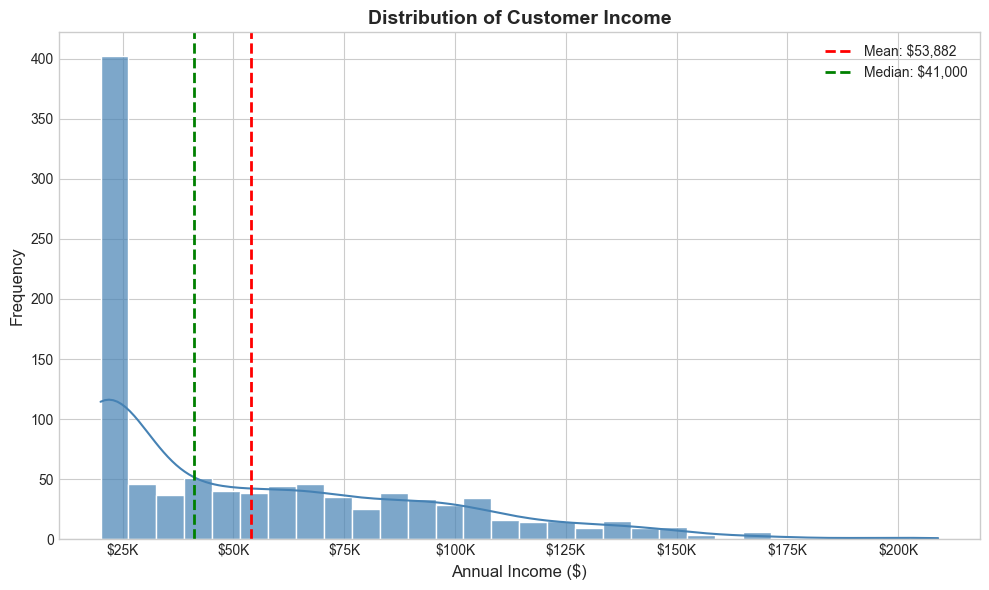


Distribution Analysis:
  Mean Income: $53,882.00
  Median Income: $41,000.00
  Skewness: 1.087
  Distribution is right-skewed


In [27]:
"""
Visualizing the distribution of customer income levels.
This helps identify the typical income range and any skewness.
"""

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with KDE overlay
sns.histplot(data=df, x='Clean_Income', bins=30, kde=True, 
             color='steelblue', edgecolor='white', alpha=0.7, ax=ax)

# Add mean and median lines for reference
mean_income = df['Clean_Income'].mean()
median_income = df['Clean_Income'].median()
ax.axvline(mean_income, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_income:,.0f}')
ax.axvline(median_income, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_income:,.0f}')

# Add labels and title
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Customer Income', fontsize=14, fontweight='bold')
ax.legend()

# Format x-axis with dollar formatting
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Statistical observation
skewness = df['Clean_Income'].skew()
print(f"\nDistribution Analysis:")
print(f"  Mean Income: ${mean_income:,.2f}")
print(f"  Median Income: ${median_income:,.2f}")
print(f"  Skewness: {skewness:.3f}")
print(f"  Distribution is {'approximately normal' if abs(skewness) < 0.5 else 'right-skewed' if skewness > 0 else 'left-skewed'}")

### Task C.2: Relationship (Scatter Plot)

Create a Scatter Plot showing the relationship between Clean_Income (`X-axis`) and Sentiment_Score (`Y-axis`).

Question: Does higher income lead to a more positive sentiment?

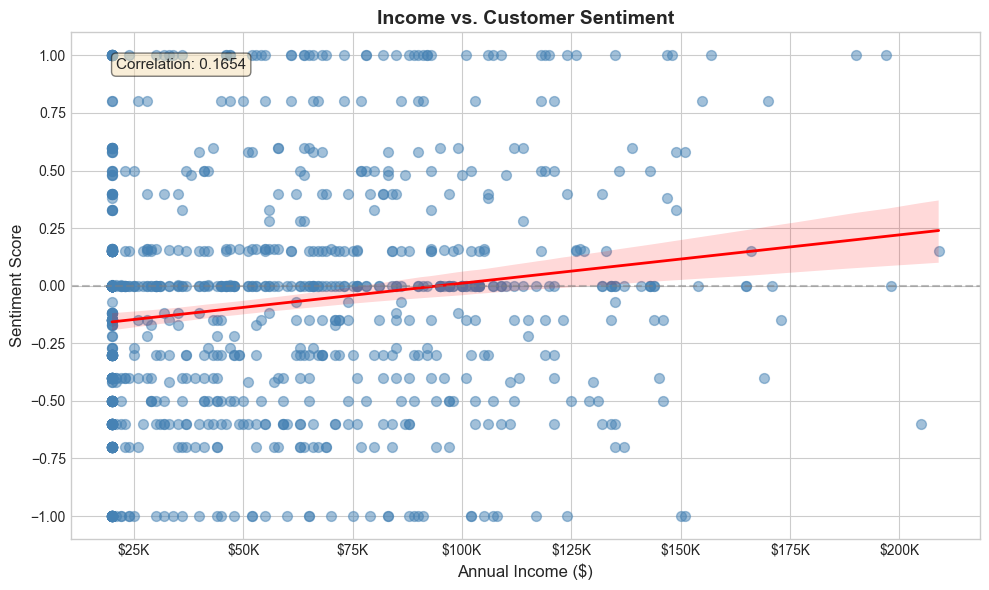


Analysis: Does higher income lead to more positive sentiment?
  Correlation coefficient: 0.1654
  Answer: There is a slight positive relationship, but it is weak.


In [28]:
"""
Visualizing the relationship between customer income and review sentiment.
This explores whether wealthier customers express more positive opinions.
"""

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create scatter plot with trend line
sns.regplot(data=df, x='Clean_Income', y='Sentiment_Score', 
            scatter_kws={'alpha': 0.5, 's': 50, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2},
            ax=ax)

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Neutral Sentiment')

# Add labels and title
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Sentiment Score', fontsize=12)
ax.set_title('Income vs. Customer Sentiment', fontsize=14, fontweight='bold')

# Format x-axis
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Calculate and display correlation
income_sentiment_corr = df['Clean_Income'].corr(df['Sentiment_Score'])
ax.text(0.05, 0.95, f'Correlation: {income_sentiment_corr:.4f}', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Answer the question
print(f"\nAnalysis: Does higher income lead to more positive sentiment?")
print(f"  Correlation coefficient: {income_sentiment_corr:.4f}")
if abs(income_sentiment_corr) < 0.1:
    print(f"  Answer: No, there is virtually no correlation between income and sentiment.")
elif income_sentiment_corr > 0:
    print(f"  Answer: There is a slight positive relationship, but it is weak.")
else:
    print(f"  Answer: There is a slight negative relationship, but it is weak.")

### Task C.3: Comparison (Bar Chart)

Create a Bar Chart comparing the average Spend_per_Visit across different Education levels. Ensure the Y-axis starts at zero.

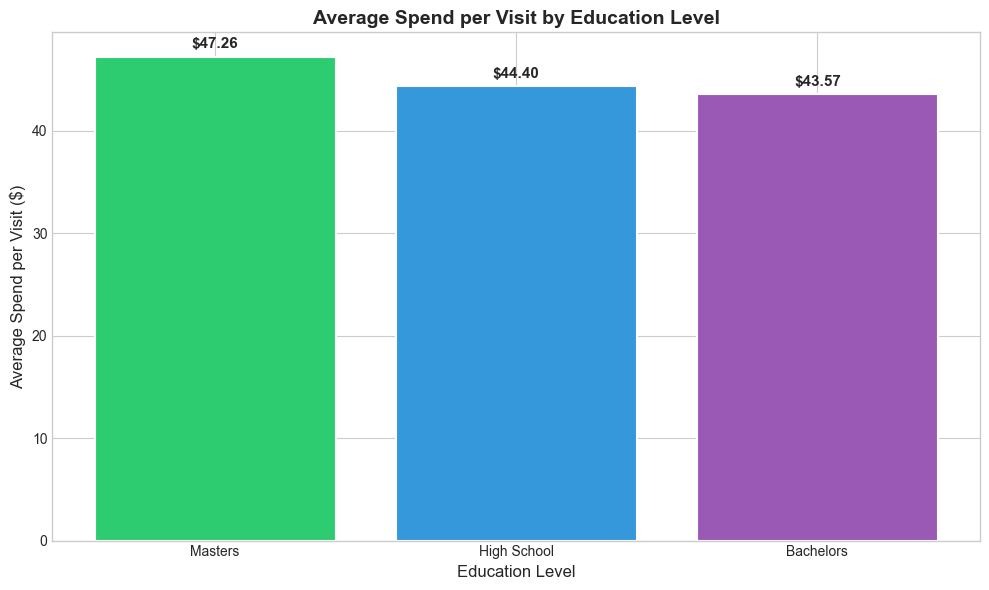


Average Spend per Visit by Education Level:
  Masters: $47.26
  High School: $44.40
  Bachelors: $43.57

Observation: Masters shows the highest average spend per visit,
while Bachelors shows the lowest.


In [29]:
"""
Comparing average spending behavior across education levels.
This reveals whether education correlates with spending patterns.
"""

# Calculate average Spend_per_Visit by Education level
education_spend = df.groupby('Education')['Spend_per_Visit'].mean().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart
bars = ax.bar(education_spend.index, education_spend.values, 
              color=['#2ecc71', '#3498db', '#9b59b6'], edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, education_spend.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'${value:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ensure Y-axis starts at zero
ax.set_ylim(bottom=0)

# Add labels and title
ax.set_xlabel('Education Level', fontsize=12)
ax.set_ylabel('Average Spend per Visit ($)', fontsize=12)
ax.set_title('Average Spend per Visit by Education Level', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print analysis
print(f"\nAverage Spend per Visit by Education Level:")
for edu, spend in education_spend.items():
    print(f"  {edu}: ${spend:.2f}")

highest = education_spend.idxmax()
lowest = education_spend.idxmin()
print(f"\nObservation: {highest} shows the highest average spend per visit,")
print(f"while {lowest} shows the lowest.")

## PART D: Predictive Modeling (M10, M11)

**Goal:** Apply supervised (Regression, KNN) and unsupervised (K-Means) models.

----------------

### Task D.1: Linear Regression (M10)

Predict the continuous numerical target: `Total_Spend`.

Training set size: 800 samples
Test set size: 200 samples

=== Linear Regression Results ===
R² Score: 0.7607

Model Coefficients:
  Clean_Income coefficient: 0.000918
  Avg_Visits coefficient: 37.011171
  Intercept: 5.6475

Interpretation:
  An R² score of 0.7607 means that 76.07% of the variation in
  customer spending is explained by their income and visit frequency.
  This suggests the model is a STRONG predictor.


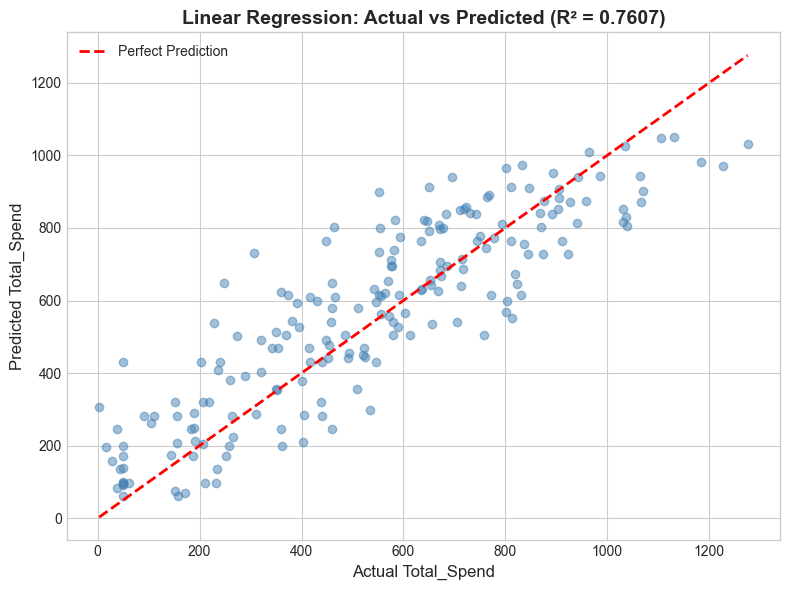

In [30]:
"""
Building a regression model to predict customer spending based on:
1. Clean_Income (customer income)
2. Avg_Visits (visit frequency)

Evaluate using R-squared score.
"""

# Define features and target
X_reg = df[['Clean_Income', 'Avg_Visits']]
y_reg = df['Total_Spend']

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = lr_model.predict(X_test)

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

# Display results
print(f"\n=== Linear Regression Results ===")
print(f"R² Score: {r2:.4f}")
print(f"\nModel Coefficients:")
print(f"  Clean_Income coefficient: {lr_model.coef_[0]:.6f}")
print(f"  Avg_Visits coefficient: {lr_model.coef_[1]:.6f}")
print(f"  Intercept: {lr_model.intercept_:.4f}")

# Interpretation
print(f"\nInterpretation:")
print(f"  An R² score of {r2:.4f} means that {r2*100:.2f}% of the variation in")
print(f"  customer spending is explained by their income and visit frequency.")
if r2 >= 0.7:
    print(f"  This suggests the model is a STRONG predictor.")
elif r2 >= 0.4:
    print(f"  This suggests the model is a MODERATE predictor.")
else:
    print(f"  This suggests the model is a WEAK predictor.")

# Visualize actual vs predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Total_Spend', fontsize=12)
ax.set_ylabel('Predicted Total_Spend', fontsize=12)
ax.set_title(f'Linear Regression: Actual vs Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Task D.2: K-Means Clustering (M11)

Segment the users into 3 groups based on their spending and income behavior.

=== K-Means Clustering Results ===

User Segment Distribution:
User_Segment
0    263
1    401
2    336
Name: count, dtype: int64

Segment Characteristics:
             Clean_Income           Total_Spend         Avg_Visits
                     mean       std        mean     std       mean
User_Segment                                                      
0               108231.94  26651.04      715.30  264.69      16.47
1                31865.34  18784.08      233.40  138.67       6.74
2                37616.07  18179.66      706.35  159.08      16.84


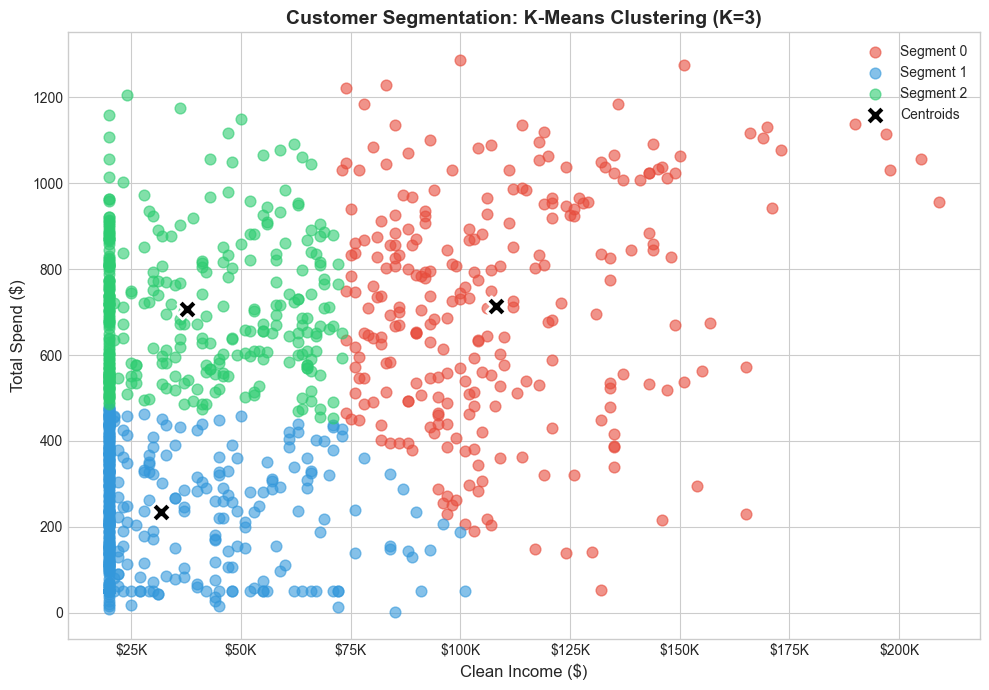


=== Segment Interpretation ===
Segment 0: High Income, High Spend (n=263)
Segment 1: Low Income, Low Spend (n=401)
Segment 2: Low Income, High Spend (n=336)


In [32]:
"""
Segment of customers into 3 distinct groups based on:
1. Clean_Income (financial capacity)
2. Total_Spend (spending behavior)

Features are scaled for optimal clustering performance.
"""

# Define features for clustering
X_cluster = df[['Clean_Income', 'Total_Spend']]

# Scale features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Initialize and fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['User_Segment'] = kmeans.fit_predict(X_scaled)

# Display segment distribution
print("=== K-Means Clustering Results ===")
print(f"\nUser Segment Distribution:")
print(df['User_Segment'].value_counts().sort_index())

# Analyze each segment
print(f"\nSegment Characteristics:")
segment_stats = df.groupby('User_Segment').agg({
    'Clean_Income': ['mean', 'std'],
    'Total_Spend': ['mean', 'std'],
    'Avg_Visits': 'mean'
}).round(2)
print(segment_stats)

# Visualize clusters
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each segment with different colors
colors = ['#e74c3c', '#3498db', '#2ecc71']
segment_names = ['Segment 0', 'Segment 1', 'Segment 2']

for segment in range(3):
    mask = df['User_Segment'] == segment
    ax.scatter(df.loc[mask, 'Clean_Income'], df.loc[mask, 'Total_Spend'],
               c=colors[segment], label=segment_names[segment], alpha=0.6, s=60)

# Plot cluster centers (transform back from scaled space)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, 
           edgecolors='white', linewidths=2, label='Centroids')

ax.set_xlabel('Clean Income ($)', fontsize=12)
ax.set_ylabel('Total Spend ($)', fontsize=12)
ax.set_title('Customer Segmentation: K-Means Clustering (K=3)', fontsize=14, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Interpret segments based on their characteristics
print(f"\n=== Segment Interpretation ===")
for seg in range(3):
    seg_data = df[df['User_Segment'] == seg]
    avg_income = seg_data['Clean_Income'].mean()
    avg_spend = seg_data['Total_Spend'].mean()
    
    income_level = "High" if avg_income > df['Clean_Income'].median() else "Low"
    spend_level = "High" if avg_spend > df['Total_Spend'].median() else "Low"
    
    print(f"Segment {seg}: {income_level} Income, {spend_level} Spend (n={len(seg_data)})")

### Task D.3: Classification (KNN) (M11)

Predict the categorical target: `Gender`.

In [33]:
"""
Building a classification model to predict customer gender based on:
1. Clean_Income
2. Total_Spend

Features are scaled for optimal KNN performance.
"""

# Define features and target
X_knn = df[['Clean_Income', 'Total_Spend']]
y_knn = df['Gender']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y_knn)

print(f"Gender classes: {le.classes_}")
print(f"Class distribution:")
print(pd.Series(y_knn).value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Scale features
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Initialize and train KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_knn)

# Display results
print(f"\n=== KNN Classification Results ===")
print(f"Accuracy Score: {accuracy:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

# Interpretation
print(f"\n=== Interpretation ===")
print(f"An accuracy of {accuracy:.4f} ({accuracy*100:.2f}%) indicates that the model is")
if accuracy >= 0.7:
    print(f"GOOD at predicting gender based on income and spending.")
elif accuracy >= 0.5:
    print(f"MODERATE at predicting gender. This is better than random guessing.")
else:
    print(f"POOR at predicting gender. Income and spending may not be strong predictors of gender.")

# Note on baseline
baseline_accuracy = max(pd.Series(y_knn).value_counts()) / len(y_knn)
print(f"\nNote: Baseline accuracy (predicting most common class) = {baseline_accuracy:.4f}")
if accuracy > baseline_accuracy:
    print(f"The model performs better than baseline.")
else:
    print(f"The model does not significantly outperform baseline.")

Gender classes: ['Female' 'Male' 'Other']
Class distribution:
Gender
Female    509
Male      446
Other      45
Name: count, dtype: int64

=== KNN Classification Results ===
Accuracy Score: 0.4550

Classification Report:
              precision    recall  f1-score   support

      Female       0.49      0.56      0.52       102
        Male       0.41      0.38      0.40        89
       Other       0.00      0.00      0.00         9

    accuracy                           0.46       200
   macro avg       0.30      0.31      0.31       200
weighted avg       0.43      0.46      0.44       200


=== Interpretation ===
An accuracy of 0.4550 (45.50%) indicates that the model is
POOR at predicting gender. Income and spending may not be strong predictors of gender.

Note: Baseline accuracy (predicting most common class) = 0.5090
The model does not significantly outperform baseline.


## PART E: Final Output and Submission

--------------------

### Task E.1: Save Processed Data

Save the final DataFrame (including all new columns: `Spend_per_Visit`, `Sentiment_Score`, `User_Segment`, etc.) to a new `CSV` file.

In [34]:
"""
Export the complete processed DataFrame with all engineered features
and model outputs to a CSV file for submission.
"""

# Define output filename
OUTPUT_FILE = 'final_processed_capstone_data.csv'

# Display final DataFrame info before saving
print("=== Final DataFrame Summary ===")
print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumns in Final Dataset:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

# Save to CSV (without index)
df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✓ Data successfully saved to '{OUTPUT_FILE}'")
print(f"\nFirst 5 rows of final data:")
df.head()

=== Final DataFrame Summary ===

Shape: 1000 rows x 12 columns

Columns in Final Dataset:
  - ID (int64)
  - Gender (object)
  - Education (object)
  - Raw_Income (object)
  - Total_Spend (float64)
  - Avg_Visits (int64)
  - Review_Text (object)
  - Clean_Income (float64)
  - Spend_per_Visit (float64)
  - Review_Word_Count (int64)
  - Sentiment_Score (float64)
  - User_Segment (int32)

✓ Data successfully saved to 'final_processed_capstone_data.csv'

First 5 rows of final data:


,ID,Gender,Education,Raw_Income,Total_Spend,Avg_Visits,Review_Text,Clean_Income,Spend_per_Visit,Review_Word_Count,Sentiment_Score,User_Segment
0,1,Male,Bachelors,36000,683.26,6,Just the facts: it is bad (Ref:1-227).,36000.0,113.876667,7,-0.7,2
1,2,Female,Masters,"$107,000",1090.29,22,My experience with this: expensive (Ref:2-467).,107000.0,49.558636,6,-0.5,0
2,3,Male,Masters,20000,597.91,18,My opinion: it is frustrating (Ref:3-620).,20000.0,33.217222,6,-0.4,2
3,4,Male,Masters,"$20,000",143.21,5,Just the facts: it is bad (Ref:4-150).,20000.0,28.642000,7,-0.7,1
4,5,Male,Bachelors,"$41,000",486.49,17,I felt it was functional (Ref:5-886).,41000.0,28.617059,6,0.0,2
